## Law Gender Bias - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target
* **Target 3:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Callable, Any
from sklearn.model_selection import train_test_split

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cached file found: wn-data/downloads/2f7260b24e923d5de63e91dc541d5d4bebab78d1
Skipping own-pt:1.0.0 (OpenWordnet-PT); already added

[nltk_data] Downloading package stopwords to nltk_data/...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_3d
from ml_moo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

In [ ]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [3]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [4]:
#train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 512,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                 data_type: str = None):
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.data_type = data_type

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'labels_{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [ ]:
def key_presence_extractor(key: str, subkey: str = None) -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey is not None:
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [ ]:
label_extractors = {
    "task_1": key_presence_extractor("vies"),
    "task_2": key_presence_extractor("vies_alvo", subkey="abs_mul"),
    "task_3": key_presence_extractor("vies_alvo", subkey="abs_")
}

In [ ]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors, data_type='train')
train_dataloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=64)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=64)


vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['']
label b 0
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['abs_mul']
label b 1
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['reu']
label b 0
vies alvo ['']

In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [ ]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
23:14:27 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:14:27 | DEBUG | ml_moo | Finding 1th individual minimum


device: cpu
available: False


Evaluating: 100%|██████████| 5/5 [01:26<00:00, 17.27s/it]
23:22:14 | DEBUG | ml_moo | Finding 2th individual minimum


device: cpu
available: False


Evaluating: 100%|██████████| 5/5 [01:22<00:00, 16.48s/it]
23:29:23 | DEBUG | ml_moo | Calculated weights: [0.50287694 0.49712306]
23:29:23 | DEBUG | ml_moo | Importance: 0.04068094760077695
23:29:23 | DEBUG | ml_moo | Global lower bound (y*): [0.61178336 0.50946686]
23:29:23 | DEBUG | ml_moo | Iteration 1
23:29:23 | DEBUG | ml_moo | Solutions list: [array([0.61178336, 0.59129962]), array([0.6926798 , 0.50946686])]


...

Evaluating: 100%|██████████| 5/5 [01:22<00:00, 16.48s/it]
01:40:26 | DEBUG | ml_moo | Calculated weights: [0.6766355 0.3233645]
01:40:26 | DEBUG | ml_moo | Importance: 0.026647598161925995
01:40:26 | DEBUG | ml_moo | Global lower bound (y*): [0.04889699 0.14430386]
01:40:26 | DEBUG | ml_moo | Iteration 20
01:40:26 | DEBUG | ml_moo | Solutions list: [array([0.04889699, 0.29952379]), array([0.12307669, 0.14430386]), array([0.10845476, 0.22094873])]


new solution added [0.04889699 0.29952379]
solution dominated [0.08557497 0.32903796]
device: cpu
available: False


Evaluating: 100%|██████████| 5/5 [01:22<00:00, 16.54s/it]
01:47:29 | DEBUG | ml_moo | Calculated weights: [0.44367597 0.55632403]
01:47:29 | DEBUG | ml_moo | Importance: 0.030657057475216354
01:47:29 | DEBUG | ml_moo | Global lower bound (y*): [0.04889699 0.14430386]
01:47:29 | DEBUG | ml_moo | Iteration 21
01:47:29 | DEBUG | ml_moo | Solutions list: [array([0.0542463 , 0.19919702]), array([0.04889699, 0.29952379]), array([0.12307669, 0.14430386])]


new solution added [0.0542463  0.19919702]
solution dominated [0.10845476 0.22094873]
device: cpu
available: False


Epoch 1/2 - Training:   0%|          | 0/5 [00:00<?, ?it/s]

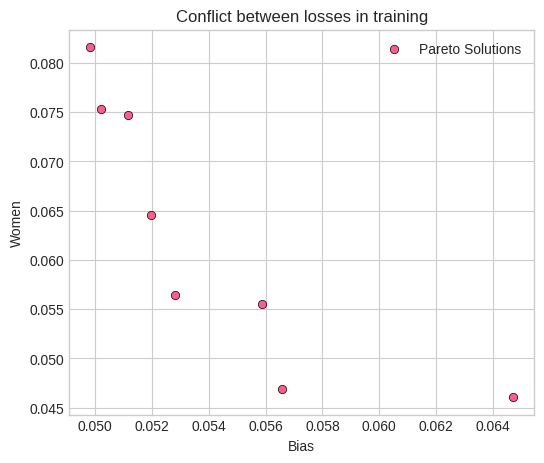

In [ ]:
title="Conflict between losses in training to detect bias"
plot_pareto_3d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [ ]:
title="Conflict between losses in training to detect bias"
plot_pareto_3d(objectives=objs, 
               labels=tuple(task_names), 
               title=title,
               #point = equal.objs,
               color="#FF5C8D"
               )

### Random Weights

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
15:56:45 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
15:56:45 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
15:56:45 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.50s/it]
15:57:02 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


...

Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.56s/it]
16:11:32 | DEBUG | ml_moo.moo.random_weights | 48th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:11:51 | DEBUG | ml_moo.moo.random_weights | 49th solution


device: cuda
available: True


Evaluating: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]
16:12:10 | DEBUG | ml_moo.moo.random_weights | 50th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from ml_moo.analysis.moo_analyzer import Analyzer

16:12:10 | WARNING | ml_moo | [Methods have different numbers of solutions: {8, 50}


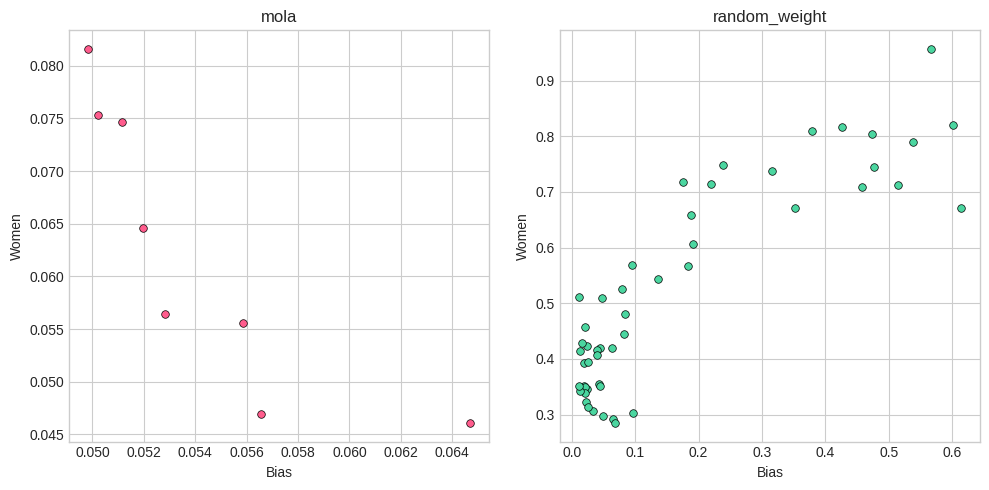

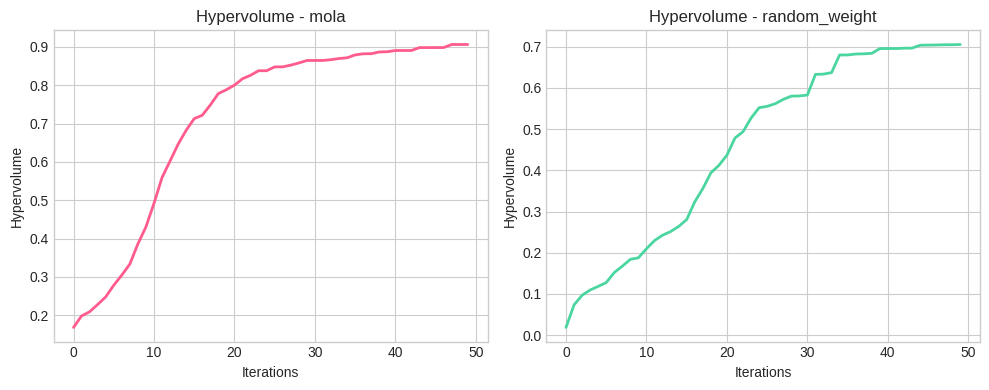

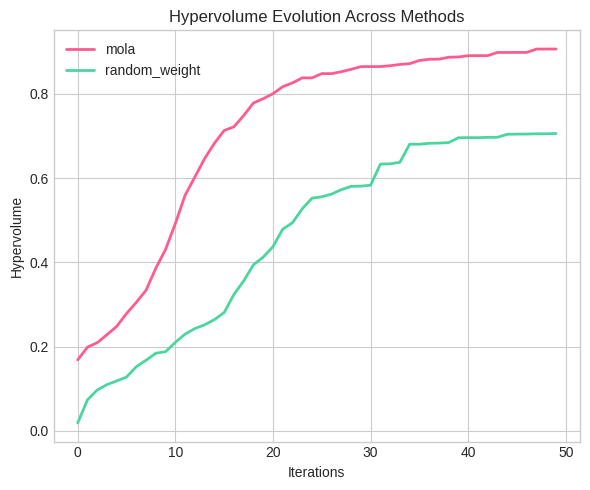

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = task_names
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [ ]:
from ml_moo.analysis.visualization import plot_pareto_3d_set_limit

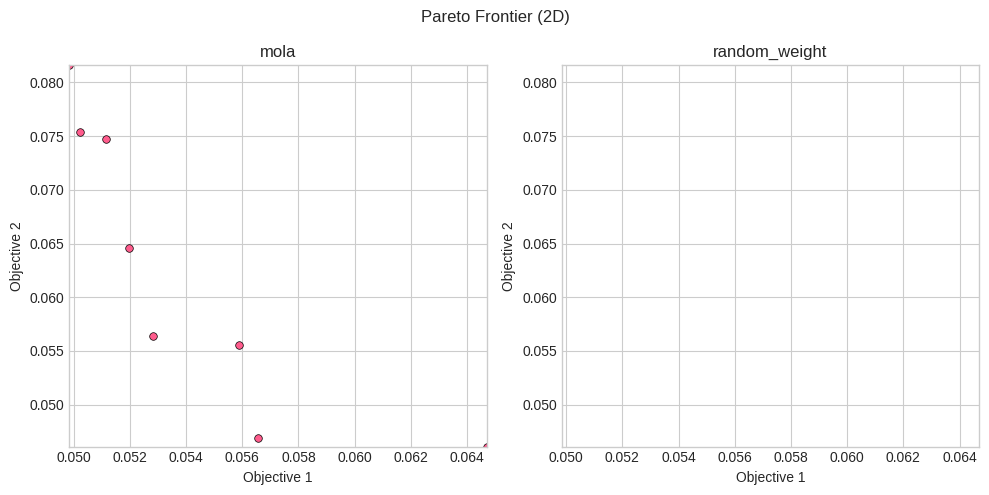

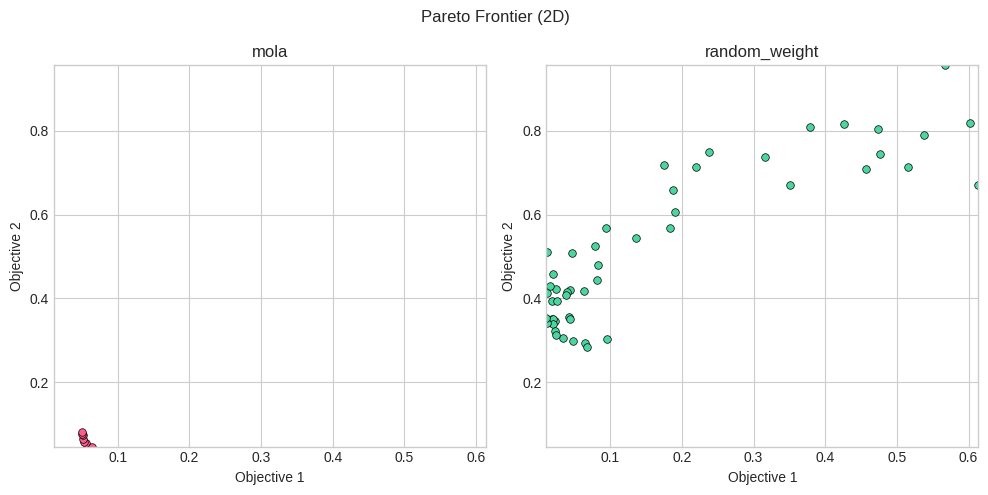

: 

In [ ]:
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_3d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 